# מטלת סיום – חלק 2 | Movie Rating Prediction

**שמות חברי הצוות + ת.ז.:** <FILL IN>

**קישור ל-GitHub:** <FILL IN>

In [1]:
# ============================================================
#  מטלת סיום – חלק 2 | Movie Rating Prediction
#  Chen Hajaj · Ariel University · Machine Learning
# ============================================================
# שמות חברי הצוות + ת.ז.:  <FILL IN>
# קישור ל-GitHub:            <FILL IN>
# ============================================================

## 1. ייבוא ספריות

In [1]:
import re
import ast
import bisect
import warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
import joblib
import matplotlib.patches as mpatches


from sklearn.linear_model    import ElasticNet
from sklearn.ensemble        import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.impute          import SimpleImputer
from sklearn.compose         import ColumnTransformer
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base            import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV
from IPython.display         import display_html

## טעינת הדאטה

In [2]:
dataset = pd.read_csv("dataset.csv", na_values=['\\N', 'N/A', 'null'], low_memory=False)
# טעינת קובץ של הבמאים 
df_crew = pd.read_csv("title.crew.tsv.gz", sep='\t', usecols=['tconst', 'directors'], low_memory=False)
# מיזוג של הקבצים לדאטה שכוללת את הבמאים 
dataset = pd.merge(dataset, df_crew, on='tconst', how='left')

## בניית פונקציות עזר לניקוי הנתונים 


In [3]:
# פונקציות ניקוי 
def _clean_year(val):
    if pd.isna(val):
        return np.nan
    try:
        year = int(float(val))
        if re.fullmatch(r'\d{4}', str(year)):
            return year
        return np.nan
    except (ValueError, TypeError):
        return np.nan 
 
def _clean_runtime(val):
    """ערך תקין: מספר בלבד (לא כחלק מטקסט)."""
    if pd.isna(val):
        return np.nan
    try:
        return float(val)
    except (ValueError, TypeError):
        return np.nan
 
def _clean_rating(val):
    """ערך תקין: מספר בין 1.0 ל-10.0."""
    if pd.isna(val):
        return np.nan
    try:
        r = float(val)
        return r if 1.0 <= r <= 10.0 else np.nan
    except (ValueError, TypeError):
        return np.nan
 
 
def _clean_genres(val):
    """מחזיר רשימת ז'אנרים נקייה."""
    if pd.isna(val):
        return []
    s = str(val).strip()
    if re.match(r'^(\\N|N/A|NA|\[\])$', s, re.IGNORECASE):
        return []
    try:
        parsed = ast.literal_eval(s)
        items  = [str(g).strip() for g in parsed] \
                 if isinstance(parsed, list) else [str(parsed).strip()]
    except (ValueError, SyntaxError):
        items = re.split(r'[,|;]', s)
    cleaned = []
    for item in items:
        g = item.strip().title()
        if g and re.match(r'^[A-Za-z\- ]{2,30}$', g):
            if not re.match(r'^(N/A|\\N|Nan|None|Na)$', g, re.IGNORECASE):
                cleaned.append(g)
    return cleaned
  
def _clean_actors(val):
    """מחלץ מזהי nm תקינים בלבד."""
    if pd.isna(val):
        return []
    s = str(val).strip()
    if re.match(r'^(\\N|\[\]|N/A)$', s, re.IGNORECASE):
        return []
    return re.findall(r'nm\d{7,8}', s)
 
 
def _clean_director(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    if re.match(r'^(\\N|N/A|NA|nan|none)$', s, re.IGNORECASE):
        return np.nan
    matches = re.findall(r'nm\d{7,8}', s)
    if not matches:
        return np.nan
    return ','.join(matches)

## Feature Engineering


In [4]:
def _safe_list(val):
    if isinstance(val, list): return val
    if pd.isna(val): return []
    try:
        parsed = ast.literal_eval(str(val))
        return parsed if isinstance(parsed, list) else [parsed]
    except Exception:
        return [x.strip() for x in str(val).split(',') if x.strip()]

def add_static_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['num_genres']  = df['genres'].apply(lambda g: len(_safe_list(g)))
    df['is_too_short'] = (df['runtimeMinutes'] < 75).astype(float)
    df['is_too_long']  = (df['runtimeMinutes'] > 150).astype(float)
    return df


## חישוב היחס בין אורך הסרט לחציון הסרטים עפי גאנר - רק סרטים של שנה קטנה מהשנה הנוכחית  
class RelativeRuntimeTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        df = X[['genres', 'startYear', 'runtimeMinutes']].copy()
        
        # חילוץ הז'אנר הראשון
        df['_first_genre'] = df['genres'].apply(
            lambda g: _safe_list(g)[0] if _safe_list(g) else 'Unknown'
        )
        
        # מסננים שורות חסרות וממיינים לפי שנה פעם אחת מראש
        df = df.dropna(subset=['startYear', 'runtimeMinutes']).sort_values('startYear')
        
        # בניית מילון ששומר לכל ז'אנר את השנים ואורכי הסרטים כמערכים מהירים
        self.genre_history_ = {}
        for genre, group in df.groupby('_first_genre'):
            self.genre_history_[genre] = {
                'years': group['startYear'].values,
                'runtimes': group['runtimeMinutes'].values
            }
            
        return self

    def transform(self, X):
        X = X.copy()
        X['_first_genre'] = X['genres'].apply(
            lambda g: _safe_list(g)[0] if _safe_list(g) else 'Unknown'
        )
        
        def calc(row):
            genre = row['_first_genre']
            current_year = row['startYear']
            
            # אם אין היסטוריה לז'אנר או שהשנה חסרה
            if genre not in self.genre_history_ or pd.isna(current_year):
                return np.nan
                
            # חיפוש בינארי מהיר למציאת נקודת החיתוך (אינדקס) של כל השנים שקטנות מהשנה הנוכחית
            years_array = self.genre_history_[genre]['years']
            idx = bisect.bisect_left(years_array, current_year)
            
            # אם האינדקס הוא 0, זה אומר שאין סרטים קודמים בז'אנר הזה
            if idx == 0:
                return np.nan
                
            # חותכים את מערך אורכי הסרטים עד לאינדקס ומחשבים חציון
            past_runtimes = self.genre_history_[genre]['runtimes'][:idx]
            median = np.median(past_runtimes)
            
            if pd.isna(median) or median == 0:
                return np.nan
                
            return row['runtimeMinutes'] / median

        X['relative_runtime_by_genre'] = X.apply(calc, axis=1)
        return X.drop(columns=['_first_genre'])
        
##חישוב כמה פעמים שחקני הסרט שיחקו בעבר 
class ActorExpTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        df = X[['lead_actors_ids', 'startYear']].dropna().copy()
        df['lead_actors_ids'] = df['lead_actors_ids'].apply(lambda x: _safe_list(x))
        df = df.explode('lead_actors_ids').sort_values('startYear')
        self.actor_years_ = df.groupby('lead_actors_ids')['startYear'].apply(list).to_dict()
        return self

    def transform(self, X):
        X = X.copy()
        def calc(row):
            actors = _safe_list(row['lead_actors_ids'])
            year = row['startYear']
            # מחזיר גם את חווית העבר וגם האם השחקן חדש
            if not actors or pd.isna(year):
                return pd.Series({'avg_actors_past_experience': 0.0, 'is_new_actors': 1.0})
            exp = [bisect.bisect_left(self.actor_years_.get(a, []), year) for a in actors]
            avg_exp = float(np.mean(exp))
            is_new = 1.0 if avg_exp == 0 else 0.0
            return pd.Series({'avg_actors_past_experience': avg_exp, 'is_new_actors': is_new})
            
        new_cols = X.apply(calc, axis=1)
        X = pd.concat([X, new_cols], axis=1)
        return X
        
class DirectorAvgTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # 1. הכנת נתונים עבור ברירות המחדל (Cold Start) - ללא כפילויות של במאים
        orig_df = X[['genres', 'startYear']].copy()
        orig_df['averageRating'] = y
        orig_df['_first_genre'] = orig_df['genres'].apply(
            lambda g: _safe_list(g)[0] if _safe_list(g) else 'Unknown'
        )
        orig_df = orig_df.dropna(subset=['startYear', 'averageRating']).sort_values('startYear')

        # נשמור היסטוריה כללית לחישוב ממוצע גלובלי וממוצע ז'אנר רץ (ללא זליגה)
        self.global_years_ = orig_df['startYear'].values
        self.global_ratings_ = orig_df['averageRating'].values

        self.genre_history_ = {}
        for g, group in orig_df.groupby('_first_genre'):
            self.genre_history_[g] = {
                'years': group['startYear'].values,
                'ratings': group['averageRating'].values
            }

        # 2. הכנת נתוני ההיסטוריה לכל במאי (עם פיצול - explode)
        df = X[['directors', 'genres', 'startYear']].copy()
        df['averageRating'] = y
        df['_first_genre'] = df['genres'].apply(
            lambda g: _safe_list(g)[0] if _safe_list(g) else 'Unknown'
        )
        df['directors'] = df['directors'].apply(lambda x: _safe_list(x))
        df = df.explode('directors').dropna(subset=['directors', 'startYear', 'averageRating']).sort_values('startYear')

        self.dir_history_ = {}
        for d, group in df.groupby('directors'):
            self.dir_history_[d] = {
                'years': group['startYear'].values,
                'ratings': group['averageRating'].values,
                'genres': group['_first_genre'].values
            }

        return self

    def transform(self, X):
        X = X.copy()
        X['_first_genre'] = X['genres'].apply(
            lambda g: _safe_list(g)[0] if _safe_list(g) else 'Unknown'
        )

        def calc(row):
            year = row['startYear']
            genre = row['_first_genre']
            current_directors = _safe_list(row['directors'])

            # במקרה קיצון של שנה חסרה, נחזיר ערכים ריקים כברירת מחדל
            if pd.isna(year):
                return pd.Series({
                    'director_past_avg': np.nan, 'is_new_director': 1.0,
                    'director_genre_past_avg': np.nan, 'director_genre_count': 0.0,
                    'is_new_director_genre': 1.0
                })

            # --- חישוב ברירות מחדל (עד לאותה שנה בלבד!) ---
            idx_global = bisect.bisect_left(self.global_years_, year)
            global_past_avg = np.mean(self.global_ratings_[:idx_global]) if idx_global > 0 else np.nan

            genre_past_avg = global_past_avg 
            if genre in self.genre_history_:
                idx_genre = bisect.bisect_left(self.genre_history_[genre]['years'], year)
                if idx_genre > 0:
                    genre_past_avg = np.mean(self.genre_history_[genre]['ratings'][:idx_genre])

            # --- איסוף היסטוריה לבמאים הנוכחיים ---
            dir_past_ratings = []
            dir_genre_past_ratings = []

            for d in current_directors:
                if d in self.dir_history_:
                    idx_d = bisect.bisect_left(self.dir_history_[d]['years'], year)
                    if idx_d > 0:
                        # שולפים רק דירוגים וז'אנרים משנים קודמות
                        past_ratings = self.dir_history_[d]['ratings'][:idx_d]
                        past_genres = self.dir_history_[d]['genres'][:idx_d]
                        
                        dir_past_ratings.extend(past_ratings)
                        
                        # מסננים רק את הסרטים שתואמים לז'אנר הנוכחי
                        mask = (past_genres == genre)
                        dir_genre_past_ratings.extend(past_ratings[mask])

            # --- הרכבת התוצאה הסופית (התמודדות עם במאי חדש) ---
            if dir_past_ratings:
                res_dir_avg = np.mean(dir_past_ratings)
                res_is_new_dir = 0.0
            else:
                res_dir_avg = global_past_avg
                res_is_new_dir = 1.0

            if dir_genre_past_ratings:
                res_dir_genre_avg = np.mean(dir_genre_past_ratings)
                res_dir_genre_count = float(len(dir_genre_past_ratings))
                res_is_new_dir_genre = 0.0
            else:
                res_dir_genre_avg = genre_past_avg
                res_dir_genre_count = 0.0
                res_is_new_dir_genre = 1.0

            # מחזירים Series כדי שניצור את כל 5 העמודות בבת אחת!
            return pd.Series({
                'director_past_avg': res_dir_avg,
                'is_new_director': res_is_new_dir,
                'director_genre_past_avg': res_dir_genre_avg,
                'director_genre_count': res_dir_genre_count,
                'is_new_director_genre': res_is_new_dir_genre
            })

        # הפעלת הפונקציה ליצירת כל העמודות החדשות ושילובן בדאטה
        new_cols = X.apply(calc, axis=1)
        X = pd.concat([X, new_cols], axis=1)

        return X.drop(columns=['_first_genre'])

## prepare_data

In [5]:
def prepare_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # מימוש פונקציות העזר של הניקוי
    df['startYear']       = df['startYear'].apply(_clean_year)
    df['runtimeMinutes']  = df['runtimeMinutes'].apply(_clean_runtime)
    df['averageRating']   = df['averageRating'].apply(_clean_rating)
    df['genres']          = df['genres'].apply(_clean_genres)
    df['lead_actors_ids'] = df['lead_actors_ids'].apply(_clean_actors)
    df['directors']       = df['directors'].apply(_clean_director)

    # הוספת הפיצ'רים הפשוטים
    df = add_static_features(df)

    #  חובה לנקות שורות ריקות לפני חישוב ההיסטוריה 
    df = df.dropna(subset=['averageRating', 'startYear']).reset_index(drop=True)

    # הסרת עמודות לא רלוונטיות
    COLS_TO_DROP = ['numVotes', 'BoxOffice', 'plot', 'Language', 'Country', 'budget',]
    df = df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns])

    return df

## 5. הכנת דאטת האימון



In [6]:
dataset_clean = prepare_data(dataset.copy())
dataset_clean = dataset_clean.dropna(subset=['averageRating']).reset_index(drop=True)

_raw = dataset.copy()
_raw['averageRating'] = _raw['averageRating'].apply(_clean_rating)
_raw['startYear']     = _raw['startYear'].apply(_clean_year)
_raw['genres']        = _raw['genres'].apply(_clean_genres)
_raw = _raw.dropna(subset=['averageRating', 'startYear']).sort_values('startYear').reset_index(drop=True)
meta_df = _raw[['primaryTitle', 'startYear', 'genres', 'directors']].copy()

y = dataset_clean['averageRating'].values
X = dataset_clean.drop(columns=['averageRating'])

# 6. הגדרת Pipeline ומודלים

In [7]:
# רשימת הפיצ'רים המספריים הסופיים 
FEATURE_COLS = [
    'startYear', 'runtimeMinutes', 'num_genres', 'is_too_short', 'is_too_long',
    'relative_runtime_by_genre', 'director_past_avg', 'avg_actors_past_experience',
    'is_new_director', 'is_new_actors', 'director_genre_past_avg', 'director_genre_count', 'is_new_director_genre']
feature_engineering_pipeline = Pipeline(steps=[
    ('relative_runtime', RelativeRuntimeTransformer()),
    ('actor_exp', ActorExpTransformer()),
    ('director_avg', DirectorAvgTransformer())])
# הגדרת ה-Preprocessor 
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ]), FEATURE_COLS)
], remainder='drop')

# הגדרת רשתות פרמטרים 
param_grid_en = {
    'alpha':    [0.001, 0.01, 0.1],
    'l1_ratio': [0.2, 0.5, 0.8],}

param_grid_rf = {
    'max_depth':        [6, 10, 15],
    'min_samples_leaf': [10, 20, 40],}

# ה-Pipelines הסופיים והמוגנים מ-Data Leakage
pipeline_en = Pipeline(steps=[
    ('feature_eng', feature_engineering_pipeline),
    ('preprocessor', preprocessor),
    ('model', GridSearchCV(
        ElasticNet(max_iter=2000, random_state=42),
        param_grid_en, cv=3, scoring='neg_mean_squared_error', n_jobs=-1
    )),
])

pipeline_rf = Pipeline(steps=[
    ('feature_eng', feature_engineering_pipeline), 
    ('preprocessor', preprocessor),
    ('model', GridSearchCV(
        RandomForestRegressor(n_estimators=60, random_state=42, n_jobs=-1),
        param_grid_rf, cv=3, scoring='neg_mean_squared_error', n_jobs=-1
    )),
])

## 8. הרצת CV

## 7. לולאת CV ידנית

### למה לולאה ידנית?

בכל fold צריך לחשב את הפיצ'רים ההיסטוריים מחדש –
רק מנתוני ה-train של אותו fold.
sklearn לא מאפשר זאת בתוך `cross_val_predict` רגיל.

### מניעת Leakage בלולאה

```
fold i:
  df_tr = שורות האימון בלבד
  df_te = שורות הבדיקה בלבד

  _build_director_past_avg(df_tr, df_te)
  ← מחפש היסטוריה רק ב-df_tr
  ← df_te לא משפיע על החישוב
```

In [8]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

def run_stability_cv(pipeline, X, y, model_name):
    fold_metrics = []
    oof_preds = np.zeros(len(y))

    for fold_num, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx],      y[test_idx]

        # אימון המודל
        pipeline.fit(X_train, y_train)

        # חיזוי
        preds_test = pipeline.predict(X_test)
        oof_preds[test_idx] = preds_test

        # חישוב מדדים
        fold_metrics.append({
            'fold': fold_num + 1,
            'r2':   r2_score(y_test, preds_test),
            'rmse': np.sqrt(mean_squared_error(y_test, preds_test)),
            'mae':  mean_absolute_error(y_test, preds_test),
        })

    metrics_df = pd.DataFrame(fold_metrics)

    print(f"\n── סיכום עבור: {model_name} ──")
    print(f"  R²:   {metrics_df['r2'].mean():.4f} ± {metrics_df['r2'].std():.4f}")
    print(f"  RMSE: {metrics_df['rmse'].mean():.4f} ± {metrics_df['rmse'].std():.4f}")
    print(f"  MAE:  {metrics_df['mae'].mean():.4f} ± {metrics_df['mae'].std():.4f}")

    return oof_preds, metrics_df

# הרצה בפועל
oof_en, stability_en = run_stability_cv(pipeline_en, X, y, 'Elastic Net')
oof_rf, stability_rf = run_stability_cv(pipeline_rf, X, y, 'Random Forest')



── סיכום עבור: Elastic Net ──
  R²:   0.2366 ± 0.0054
  RMSE: 1.1295 ± 0.0103
  MAE:  0.8639 ± 0.0081

── סיכום עבור: Random Forest ──
  R²:   0.2980 ± 0.0078
  RMSE: 1.0831 ± 0.0084
  MAE:  0.8223 ± 0.0080


## 10. ניתוח שגיאות (Error Analysis)

In [20]:
### 10.1 – בניית DataFrame שגיאות
errors_df = X[['tconst', 'primaryTitle', 'startYear', 'genres', 'directors']].copy()
errors_df['y_true']   = y
errors_df['pred_rf']  = oof_rf
errors_df['pred_en']  = oof_en
errors_df['error_rf'] = oof_rf - y   # חיובי = overprediction
errors_df['error_en'] = oof_en - y
errors_df['first_genre'] = errors_df['genres'].apply(
    lambda g: g[0] if isinstance(g, list) and g else 'Unknown'
)
# מעבירים את טבלת X דרך צינור הפיצ'רים שלנו באופן חד-פעמי רק כדי לחשב את הערכים עבור ניתוח השגיאות
X_engineered = feature_engineering_pipeline.fit_transform(X, y)
errors_df['num_genres'] = X['num_genres'].values
errors_df['director_past_avg']   = X_engineered['director_past_avg'].values
errors_df['avg_actors_past_exp'] = X_engineered['avg_actors_past_experience'].values
errors_df['is_new_director']= X_engineered['is_new_director'].values

In [21]:
### 10.2 – חילוץ 20 ה-outliers לכל מודל
# Random Forest (המודל הטוב יותר)
over_rf  = errors_df.nlargest(10,  'error_rf')
under_rf = errors_df.nsmallest(10, 'error_rf')
outliers_rf = pd.concat([over_rf, under_rf])

# Elastic Net
over_en  = errors_df.nlargest(10,  'error_en')
under_en = errors_df.nsmallest(10, 'error_en')
outliers_en = pd.concat([over_en, under_en])

COLS_SHOW = ['primaryTitle', 'startYear', 'first_genre', 'y_true', 'pred_rf', 'error_rf','is_new_director']
print("── 10 Overpredictions גדולות ביותר (Random Forest) ──")
display(over_rf[COLS_SHOW].round(2))
print("\n── 10 Underpredictions גדולות ביותר (Random Forest) ──")
display(under_rf[COLS_SHOW].round(2))


── 10 Overpredictions גדולות ביותר (Random Forest) ──


,primaryTitle,startYear,first_genre,y_true,pred_rf,error_rf,is_new_director
8633,Justin Bieber: Always Believing,2012.0,Documentary,1.0,7.19,6.19,1.0
43217,Rape of the Soul,2006.0,Documentary,1.7,7.75,6.05,1.0
36581,Play in the Gray,2009.0,Biography,1.3,7.20,5.90,1.0
12414,Kurz,2023.0,Documentary,1.2,7.09,5.89,0.0
30164,Obama in NC: The Path to History,2010.0,Documentary,1.5,7.29,5.79,1.0
43273,Ramo Trip,2012.0,Documentary,1.4,7.19,5.79,0.0
69572,We Love Bad Boys,2024.0,Comedy,1.2,6.97,5.77,1.0
87291,Brush with Life: The Art of Being Edward Biberman,2007.0,Documentary,1.5,7.18,5.68,1.0
27120,Our Drawings,2023.0,Adventure,1.2,6.75,5.55,1.0
67979,Vixen Highway 2006: It Came from Uranus!,2010.0,Action,1.2,6.69,5.49,1.0



── 10 Underpredictions גדולות ביותר (Random Forest) ──


,primaryTitle,startYear,first_genre,y_true,pred_rf,error_rf,is_new_director
47979,Son-nim-1 Cheo-beon-jjae I-ya-gi,2011.0,Horror,9.1,4.38,-4.72,1.0
32440,One Direction: I Love One Direction,2013.0,Documentary,9.2,4.48,-4.72,0.0
104046,Hantu Nan Sempit,2014.0,Action,8.7,4.07,-4.63,0.0
14891,Long Shot Louie,2023.0,Action,8.1,3.57,-4.53,0.0
29350,Oscuro by Rene Potter,2016.0,Horror,8.6,4.08,-4.52,1.0
30106,One Night Out,2018.0,Thriller,9.0,4.60,-4.40,0.0
34089,Puli Vachindi Meka Chachindi,2021.0,Thriller,9.5,5.22,-4.28,1.0
58896,Akkada Varu Ikkada Unnaru,2024.0,Horror,9.1,4.83,-4.27,1.0
18978,Monster,2024.0,Fantasy,9.3,5.07,-4.23,0.0
102709,Good Intentions,2014.0,Drama,9.4,5.20,-4.20,1.0


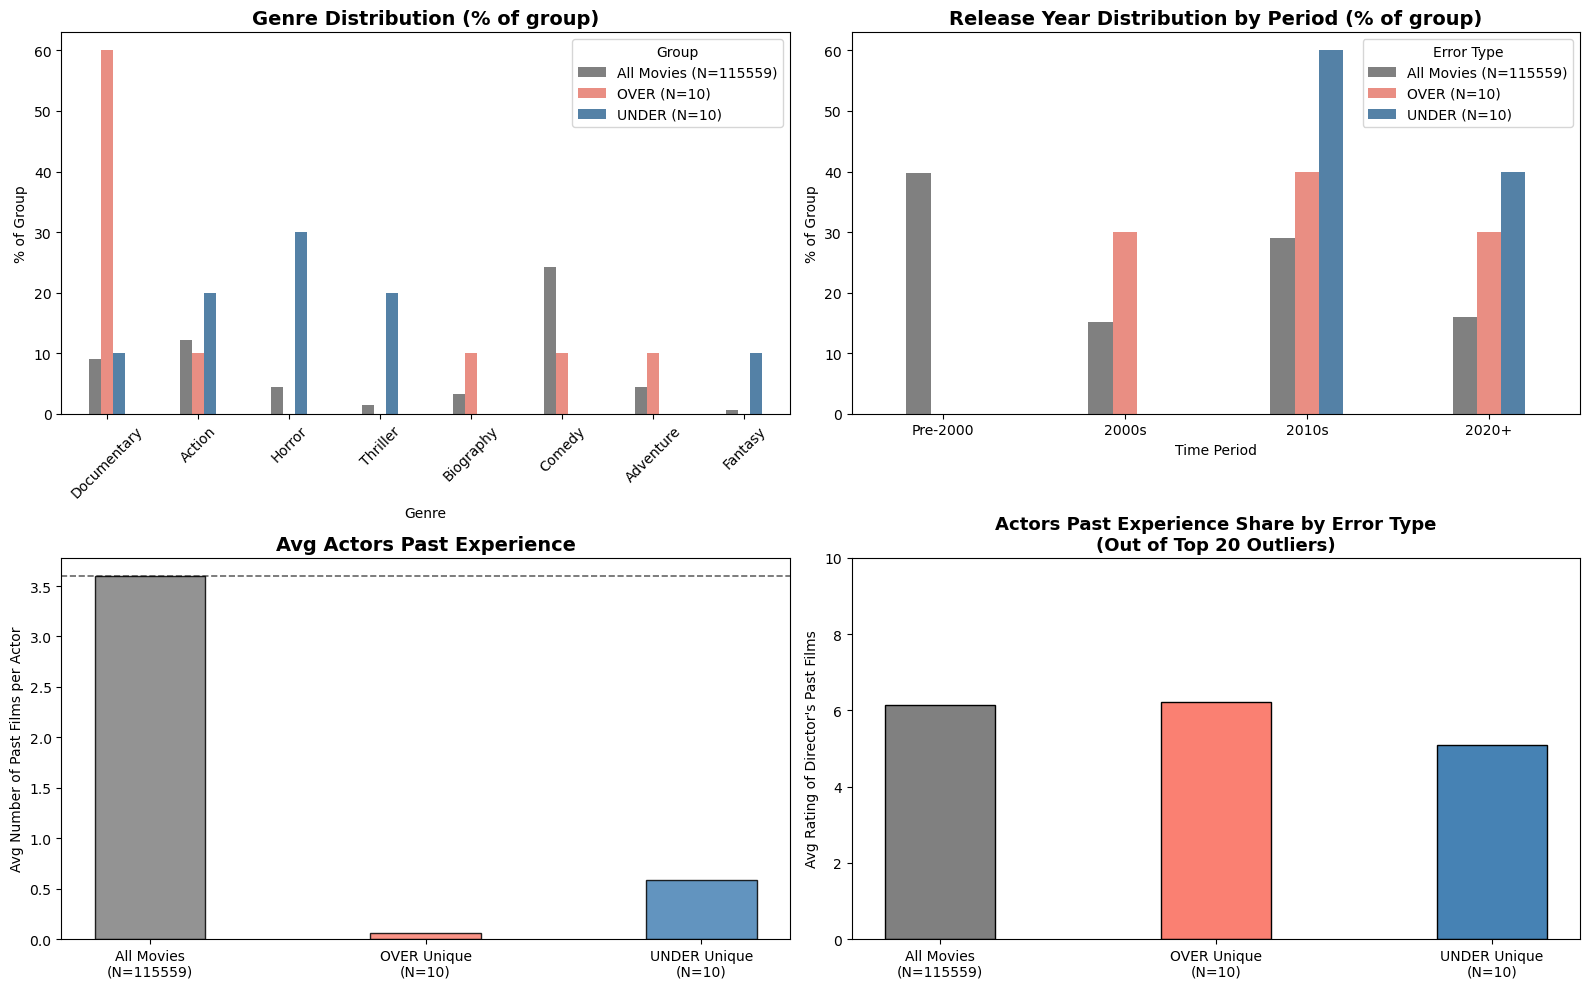

In [65]:
# 10.3 Pattern analysis 
# הגדרת סיווג השגיאה (חיובי = OVER, שלילי = UNDER) לצורך הצגה בגרף
outliers_rf['Error Type'] = outliers_rf['error_rf'].apply(
    lambda x: 'OVER' if x >= 0 else 'UNDER')
FEAT_COLS = ['director_past_avg', 'avg_actors_past_exp']
custom_colors = ['gray', 'salmon', 'steelblue']
# יצירת לייבלים חכמים שכוללים את ה-N של כל קבוצה
smart_groups = [f'All Movies\n(N={n_all})', 
    f'OVER Unique\n(N={n_over})', 
    f'UNDER Unique\n(N={n_under})'] 

all_means   = errors_df[FEAT_COLS].mean()
over_means  = over_rf[FEAT_COLS].mean()
under_means = under_rf[FEAT_COLS].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
# מכין % per genre לכל קבוצה
top_genres = outliers_rf['first_genre'].value_counts().head(8).index.tolist()
rows = []
for genre in top_genres:
    rows.append({'Genre': genre, 'Group': f'All Movies (N={n_all})',
                 'Pct': (errors_df['first_genre'] == genre).mean() * 100})
    rows.append({'Genre': genre, 'Group': f'OVER (N={n_over})',
                 'Pct': (over_rf['first_genre'] == genre).mean() * 100})
    rows.append({'Genre': genre, 'Group': f'UNDER (N={n_under})',
                 'Pct': (under_rf['first_genre'] == genre).mean() * 100})
genre_plot_df = pd.DataFrame(rows)
sns.barplot(data=genre_plot_df, x='Genre', y='Pct', hue='Group',
            palette={f'All Movies (N={n_all})': 'gray',
                     f'OVER (N={n_over})':       'salmon',
                     f'UNDER (N={n_under})':     'steelblue'}, ax=axes[0, 0], width=0.4)
axes[0, 0].set_title('Genre Distribution (% of group)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Genre')
axes[0, 0].set_ylabel('% of Group')
axes[0, 0].tick_params(axis='x', rotation=45)

def year_to_period(y):
    if pd.isna(y):    return 'Unknown'
    if y < 2000:      return 'Pre-2000'
    elif y < 2010:    return '2000s'
    elif y < 2020:    return '2010s'
    else:             return '2020+'

periods = ['Pre-2000', '2000s', '2010s', '2020+']

rows = []
for period in periods:
    rows.append({'Period': period, 'Group': f'All Movies (N={n_all})',
                 'Pct': (errors_df['startYear'].apply(year_to_period) == period).mean() * 100})
    rows.append({'Period': period, 'Group': f'OVER (N={n_over})',
                 'Pct': (over_rf['startYear'].apply(year_to_period) == period).mean() * 100})
    rows.append({'Period': period, 'Group': f'UNDER (N={n_under})',
                 'Pct': (under_rf['startYear'].apply(year_to_period) == period).mean() * 100})

year_plot_df = pd.DataFrame(rows)

sns.barplot(data=year_plot_df, x='Period', y='Pct', hue='Group',
            palette={f'All Movies (N={n_all})': 'gray',
                     f'OVER (N={n_over})':       'salmon',
                     f'UNDER (N={n_under})':     'steelblue'},
            ax=axes[0, 1], width=0.4)
axes[0, 1].set_title('Release Year Distribution by Period (% of group)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Time Period')
axes[0, 1].set_ylabel('% of Group')
axes[0, 1].legend(title='Error Type')

n_all   = len(errors_df)
n_over  = len(over_rf)
n_under = len(under_rf)

act_vals = [all_means['avg_actors_past_exp'],
            over_means['avg_actors_past_exp'],
            under_means['avg_actors_past_exp']]

# ציור הברים עם הלייבלים החכמים
bars_act = axes[1, 0].bar(smart_groups, act_vals, color=custom_colors, edgecolor='black', alpha=0.85, width=0.4)
axes[1, 0].set_title('Avg Actors Past Experience', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Avg Number of Past Films per Actor')

# הוספת קו ייחוס אופקי שמראה את הממוצע הכללי כדי להדגיש את הפער!
axes[1, 0].axhline(all_means['avg_actors_past_exp'], color='black', linestyle='--', alpha=0.6, linewidth=1.2)

avg_new_over  = over_rf['director_past_avg'].mean()
avg_new_under = under_rf['director_past_avg'].mean()
avg_all_movies = errors_df['director_past_avg'].mean()

avg = [avg_all_movies,avg_new_over, avg_new_under]
axes[1, 1].bar(smart_groups, avg, color=custom_colors, edgecolor='black', width=0.4)
axes[1, 1].set_title("Actors Past Experience Share by Error Type\n(Out of Top 20 Outliers)", fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel("Avg Rating of Director's Past Films")
axes[1, 1].set_ylim(0, 10)


plt.tight_layout()
plt.show()

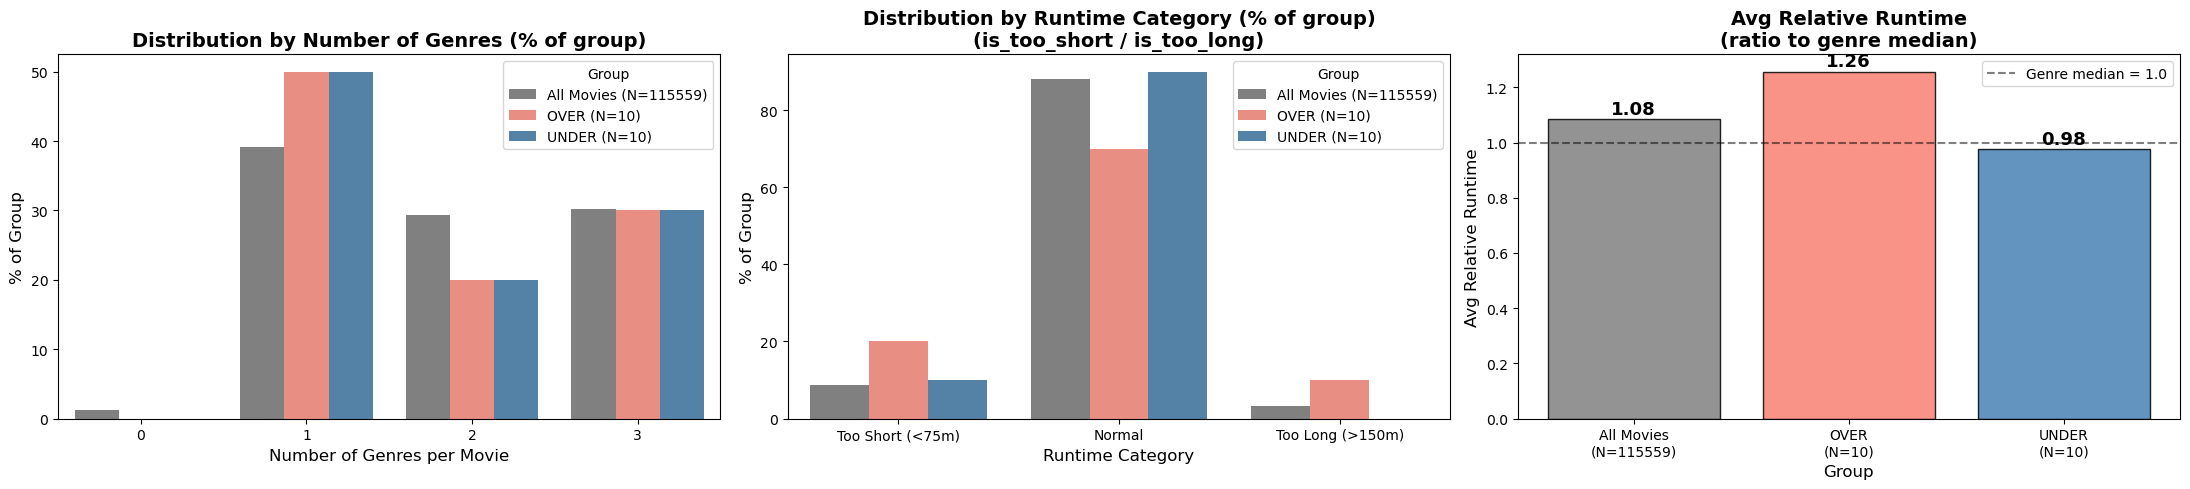

In [62]:
def runtime_cat(s, l):
    return 'Too Short (<75m)' if s == 1 else ('Too Long (>150m)' if l == 1 else 'Normal')

outliers_rf = outliers_rf.copy()
outliers_rf['is_too_short']     = X.loc[outliers_rf.index, 'is_too_short'].values
outliers_rf['is_too_long']      = X.loc[outliers_rf.index, 'is_too_long'].values
outliers_rf['relative_runtime'] = X_engineered.loc[outliers_rf.index, 'relative_runtime_by_genre'].values
outliers_rf['runtime_category'] = [runtime_cat(s, l) for s, l in
                                   zip(outliers_rf['is_too_short'], outliers_rf['is_too_long'])]
outliers_rf['Error Type']       = outliers_rf['error_rf'].apply(lambda e: 'OVER' if e >= 0 else 'UNDER')

# runtime_category לכלל הסרטים (שורה אחת, ללא copy של errors_df)
all_rt_cat = pd.Series([runtime_cat(s, l) for s, l in zip(X['is_too_short'].values, X['is_too_long'].values)],
                       index=errors_df.index)

# helper — בונה DataFrame עם % per category לשלוש קבוצות
def make_pct_df(categories, all_ser, over_ser, under_ser, col='Category'):
    rows = []
    for cat in categories:
        rows += [
            {col: cat, 'Group': f'All Movies (N={n_all})', 'Pct': (all_ser  == cat).mean() * 100},
            {col: cat, 'Group': f'OVER (N={n_over})',       'Pct': (over_ser  == cat).mean() * 100},
            {col: cat, 'Group': f'UNDER (N={n_under})',     'Pct': (under_ser == cat).mean() * 100},
        ]
    return pd.DataFrame(rows)

pal = {f'All Movies (N={n_all})': 'gray', f'OVER (N={n_over})': 'salmon', f'UNDER (N={n_under})': 'steelblue'}

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# [0] num_genres
ng_cats = sorted(errors_df['num_genres'].unique())
sns.barplot(data=make_pct_df(ng_cats, errors_df['num_genres'],
                             over_rf['num_genres'], under_rf['num_genres'], col='num_genres'),
            x='num_genres', y='Pct', hue='Group', palette=pal, ax=axes[0])
axes[0].set_title('Distribution by Number of Genres (% of group)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Genres per Movie', fontsize=12)
axes[0].set_ylabel('% of Group', fontsize=12)
axes[0].legend(title='Group')

# [1] runtime_category
rt_cats = ['Too Short (<75m)', 'Normal', 'Too Long (>150m)']
sns.barplot(data=make_pct_df(rt_cats, all_rt_cat,
                             outliers_rf.loc[over_rf.index, 'runtime_category'],
                             outliers_rf.loc[under_rf.index, 'runtime_category']),
            x='Category', y='Pct', hue='Group', palette=pal, ax=axes[1])
axes[1].set_title('Distribution by Runtime Category (% of group)\n(is_too_short / is_too_long)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Runtime Category', fontsize=12)
axes[1].set_ylabel('% of Group', fontsize=12)
axes[1].legend(title='Group')

# [2] relative runtime
rrt_vals   = [X_engineered['relative_runtime_by_genre'].mean(),
              outliers_rf.loc[over_rf.index,  'relative_runtime'].mean(),
              outliers_rf.loc[under_rf.index, 'relative_runtime'].mean()]
bar_labels = [f'All Movies\n(N={n_all})', f'OVER\n(N={n_over})', f'UNDER\n(N={n_under})']
bars = axes[2].bar(bar_labels, rrt_vals, color=['gray','salmon','steelblue'], edgecolor='black', alpha=0.85)
axes[2].axhline(1.0, color='black', linestyle='--', alpha=0.5, label='Genre median = 1.0')
axes[2].set_title('Avg Relative Runtime\n(ratio to genre median)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Group', fontsize=12)
axes[2].set_ylabel('Avg Relative Runtime', fontsize=12)
axes[2].legend()
for bar, v in zip(bars, rrt_vals):
    if not np.isnan(v):
        axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.2f}',
                     ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [40]:
movie_name = "Justin Bieber: Always Believing"  # ← שנה לשם הסרט

matches = errors_df[errors_df['primaryTitle'].str.contains(movie_name, case=False, na=False)]
if matches.empty:
    print(f"❌ לא נמצא סרט עם השם '{movie_name}'")
else:
    row        = matches.iloc[0]
    in_out     = row.name in outliers_rf.index
    err_type   = 'OVER' if row['error_rf'] >= 0 else 'UNDER'

    # is_new_director — מ-errors_df אם קיים, אחרת מ-X
    if 'is_new_director' in errors_df.columns:
        is_new_dir = errors_df.at[row.name, 'is_new_director'] == 1.0
    elif row.name in X.index:
        is_new_dir = X.at[row.name, 'is_new_director'] == 1.0
    else:
        is_new_dir = None

    print(f"{'='*60}")
    print(f"  {row['primaryTitle']}  ({int(row['startYear'])})")
    print(f"{'='*60}")
    print(f"  דירוג אמיתי : {row['y_true']:.1f}")
    print(f"  תחזית RF    : {row['pred_rf']:.2f}")
    print(f"  שגיאה       : {row['error_rf']:+.2f}  →  {err_type}")
    print()

    print(f"  ז'אנר ראשון : {row['first_genre']}")
    print()

    print(f"  שנת יציאה : {int(row['startYear'])}")
    print()

    print(f"  ניסיון שחקנים (סרט זה) : {row['avg_actors_past_exp']:.1f}")
    print(f"  ממוצע ALL movies        : {errors_df['avg_actors_past_exp'].mean():.1f}")
    print(f"  ממוצע OVER (top-10)     : {over_rf['avg_actors_past_exp'].mean():.1f}")
    print(f"  ממוצע UNDER (top-10)    : {under_rf['avg_actors_past_exp'].mean():.1f}")
    print()
    print(f"  מספר ז'אנרים : {row['num_genres']:.1f} ")
    print()
    if is_new_dir is not None:
        print(f"  במאי חדש (is_new_director=1) : {'כן ✅' if is_new_dir else 'לא ❌'}")


  Justin Bieber: Always Believing  (2012)
  דירוג אמיתי : 1.0
  תחזית RF    : 7.19
  שגיאה       : +6.19  →  OVER

  ז'אנר ראשון : Documentary

  שנת יציאה : 2012

  ניסיון שחקנים (סרט זה) : 0.0
  ממוצע ALL movies        : 3.6
  ממוצע OVER (top-10)     : 0.1
  ממוצע UNDER (top-10)    : 0.6

  מספר ז'אנרים : 2.0 

  במאי חדש (is_new_director=1) : כן ✅


In [60]:
### 10.4 – השוואה בין המודלים
overlap_idx = outliers_rf.index.intersection(outliers_en.index)
print(f"חפיפה בין המודלים: {len(overlap_idx)} סרטים מתוך 20")
print(f"\nסרטים שמופיעים אצל שניהם:")
join=display(errors_df.loc[overlap_idx, ['primaryTitle', 'y_true', 'pred_rf', 'pred_en', 'error_rf', 'error_en']].round(2))
print(join)

חפיפה בין המודלים: 9 סרטים מתוך 20

סרטים שמופיעים אצל שניהם:


,primaryTitle,y_true,pred_rf,pred_en,error_rf,error_en
8633,Justin Bieber: Always Believing,1.0,7.19,6.85,6.19,5.85
43217,Rape of the Soul,1.7,7.75,7.39,6.05,5.69
12414,Kurz,1.2,7.09,7.14,5.89,5.94
30164,Obama in NC: The Path to History,1.5,7.29,7.15,5.79,5.65
43273,Ramo Trip,1.4,7.19,7.22,5.79,5.82
67979,Vixen Highway 2006: It Came from Uranus!,1.2,6.69,7.36,5.49,6.16
32440,One Direction: I Love One Direction,9.2,4.48,4.90,-4.72,-4.30
104046,Hantu Nan Sempit,8.7,4.07,3.92,-4.63,-4.78
14891,Long Shot Louie,8.1,3.57,3.23,-4.53,-4.87


None


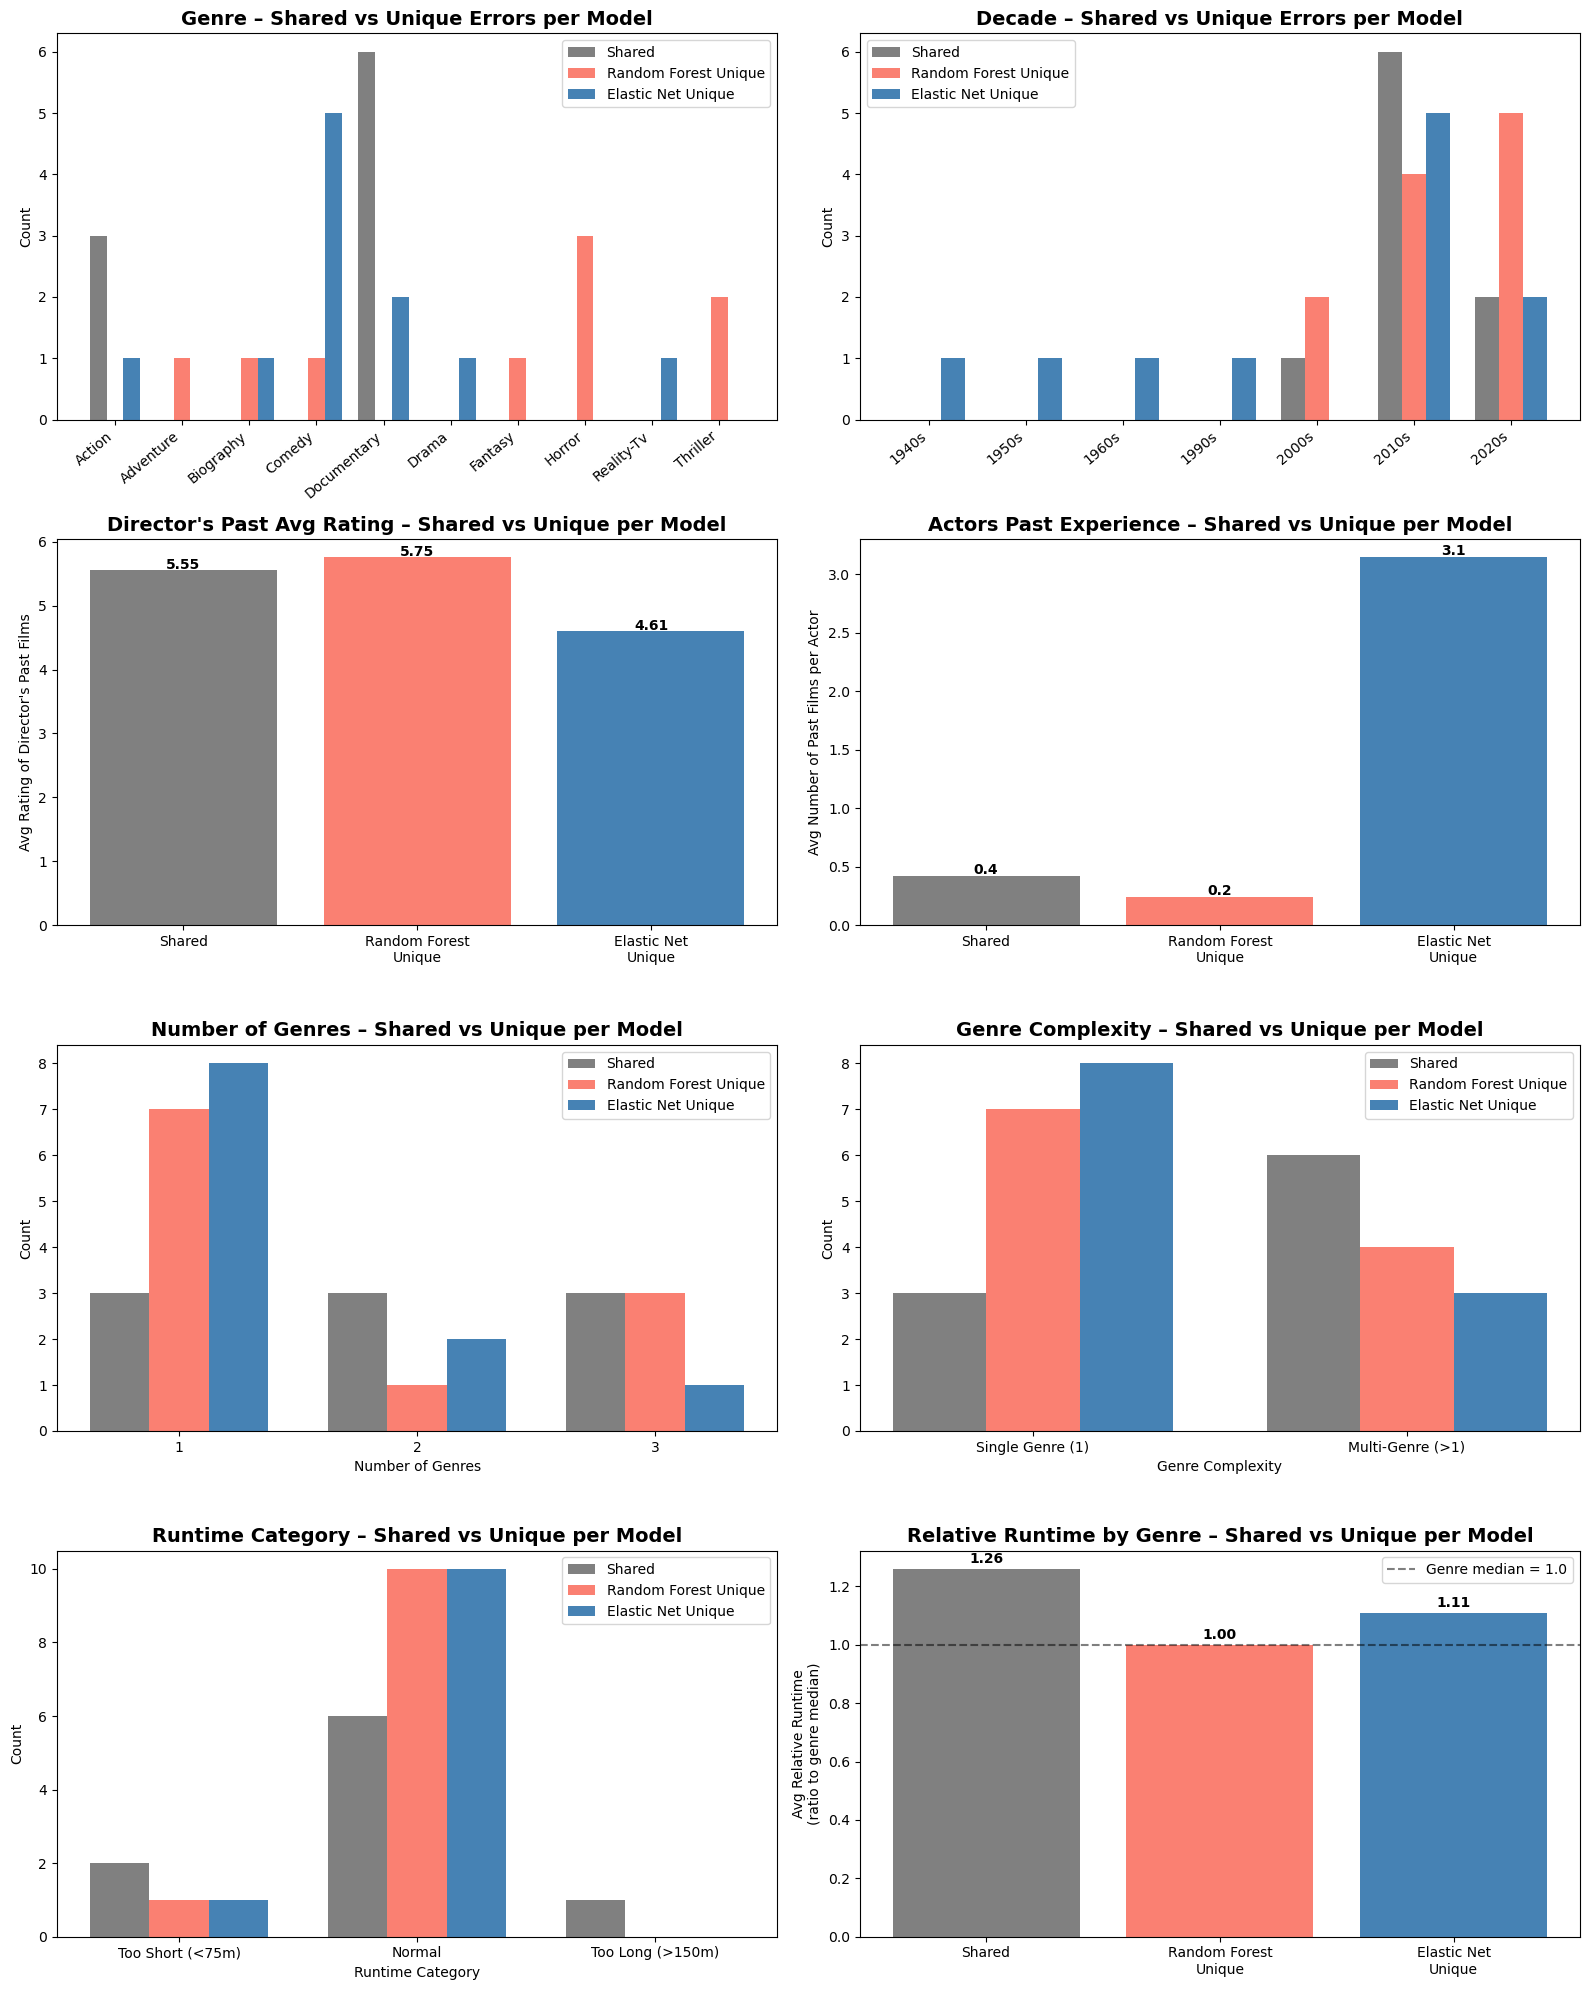

In [61]:
best_name  = "Random Forest"
other_name = "Elastic Net"

# מה שייחודי לכל מודל
only_best  = outliers_rf.index.difference(outliers_en.index)
only_other = outliers_en.index.difference(outliers_rf.index)

sub_best   = errors_df.loc[only_best]
sub_other  = errors_df.loc[only_other]
sub_shared = errors_df.loc[overlap_idx]

groups = ['Shared', f'{best_name}\nUnique', f'{other_name}\nUnique']
colors = ['gray', 'salmon', 'steelblue']
w = 0.25

fig, axes = plt.subplots(4, 2, figsize=(16, 20))

# [0,0] – ז'אנר
genre_shared = sub_shared['first_genre'].value_counts().head(6)
genre_best   = sub_best['first_genre'].value_counts().head(6)
genre_other  = sub_other['first_genre'].value_counts().head(6)
all_genres   = sorted(set(genre_shared.index) | set(genre_best.index) | set(genre_other.index))
x = range(len(all_genres))
axes[0, 0].bar([i - w for i in x], [genre_shared.get(g, 0) for g in all_genres], w, label='Shared',              color='gray')
axes[0, 0].bar([i     for i in x], [genre_best.get(g, 0)   for g in all_genres], w, label=f'{best_name} Unique', color='salmon')
axes[0, 0].bar([i + w for i in x], [genre_other.get(g, 0)  for g in all_genres], w, label=f'{other_name} Unique',color='steelblue')
axes[0, 0].set_xticks(list(x))
axes[0, 0].set_xticklabels(all_genres, rotation=40, ha='right')
axes[0, 0].set_title('Genre – Shared vs Unique Errors per Model', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()

# [0,1] – עשור
dec_shared = (sub_shared['startYear'] // 10 * 10).value_counts().sort_index()
dec_best   = (sub_best['startYear']   // 10 * 10).value_counts().sort_index()
dec_other  = (sub_other['startYear']  // 10 * 10).value_counts().sort_index()
all_dec    = sorted(set(dec_shared.index) | set(dec_best.index) | set(dec_other.index))
dec_labels = [f"{int(d)}s" for d in all_dec]
x = range(len(all_dec))
axes[0, 1].bar([i - w for i in x], [dec_shared.get(d, 0) for d in all_dec], w, label='Shared',              color='gray')
axes[0, 1].bar([i     for i in x], [dec_best.get(d, 0)   for d in all_dec], w, label=f'{best_name} Unique', color='salmon')
axes[0, 1].bar([i + w for i in x], [dec_other.get(d, 0)  for d in all_dec], w, label=f'{other_name} Unique',color='steelblue')
axes[0, 1].set_xticks(list(x))
axes[0, 1].set_xticklabels(dec_labels, rotation=40, ha='right')
axes[0, 1].set_title('Decade – Shared vs Unique Errors per Model', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()

# [1,0] – Director Past Avg
dir_v = [sub_shared['director_past_avg'].mean(),
         sub_best['director_past_avg'].mean(),
         sub_other['director_past_avg'].mean()]
bars = axes[1, 0].bar(groups, dir_v, color=colors)
axes[1, 0].set_title("Director's Past Avg Rating – Shared vs Unique per Model", fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel("Avg Rating of Director's Past Films")
for bar, v in zip(bars, dir_v):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2,
                    v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

# [1,1] – Actors Past Experience
act_v = [sub_shared['avg_actors_past_exp'].mean(),
         sub_best['avg_actors_past_exp'].mean(),
         sub_other['avg_actors_past_exp'].mean()]
bars = axes[1, 1].bar(groups, act_v, color=colors)
axes[1, 1].set_title('Actors Past Experience – Shared vs Unique per Model', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Avg Number of Past Films per Actor')
for bar, v in zip(bars, act_v):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2,
                    v + 0.02, f'{v:.1f}', ha='center', fontweight='bold')

# [2,0] – מספר ז'אנרים מדויק
num_genres_shared = sub_shared['num_genres'].value_counts().sort_index()
num_genres_best   = sub_best['num_genres'].value_counts().sort_index()
num_genres_other  = sub_other['num_genres'].value_counts().sort_index()
all_nums          = sorted(set(num_genres_shared.index) | set(num_genres_best.index) | set(num_genres_other.index))
x_nums            = range(len(all_nums))
axes[2, 0].bar([i - w for i in x_nums], [num_genres_shared.get(n, 0) for n in all_nums], w, label='Shared',              color='gray')
axes[2, 0].bar([i     for i in x_nums], [num_genres_best.get(n, 0)   for n in all_nums], w, label=f'{best_name} Unique', color='salmon')
axes[2, 0].bar([i + w for i in x_nums], [num_genres_other.get(n, 0)  for n in all_nums], w, label=f'{other_name} Unique',color='steelblue')
axes[2, 0].set_xticks(list(x_nums))
axes[2, 0].set_xticklabels([str(n) for n in all_nums])
axes[2, 0].set_title('Number of Genres – Shared vs Unique per Model', fontsize=14, fontweight='bold')
axes[2, 0].set_ylabel('Count')
axes[2, 0].set_xlabel('Number of Genres')
axes[2, 0].legend()

# [2,1] – מורכבות הז'אנר (בוליאני)
comp_shared = sub_shared['num_genres'].apply(lambda x: 'Single Genre (1)' if x == 1 else 'Multi-Genre (>1)').value_counts()
comp_best   = sub_best['num_genres'].apply(  lambda x: 'Single Genre (1)' if x == 1 else 'Multi-Genre (>1)').value_counts()
comp_other  = sub_other['num_genres'].apply( lambda x: 'Single Genre (1)' if x == 1 else 'Multi-Genre (>1)').value_counts()
all_comps   = ['Single Genre (1)', 'Multi-Genre (>1)']
x_comps     = range(len(all_comps))
axes[2, 1].bar([i - w for i in x_comps], [comp_shared.get(c, 0) for c in all_comps], w, label='Shared',              color='gray')
axes[2, 1].bar([i     for i in x_comps], [comp_best.get(c, 0)   for c in all_comps], w, label=f'{best_name} Unique', color='salmon')
axes[2, 1].bar([i + w for i in x_comps], [comp_other.get(c, 0)  for c in all_comps], w, label=f'{other_name} Unique',color='steelblue')
axes[2, 1].set_xticks(list(x_comps))
axes[2, 1].set_xticklabels(all_comps)
axes[2, 1].set_title('Genre Complexity – Shared vs Unique per Model', fontsize=14, fontweight='bold')
axes[2, 1].set_ylabel('Count')
axes[2, 1].set_xlabel('Genre Complexity')
axes[2, 1].legend()

# [3,0] – Runtime Category (Too Short / Normal / Too Long)
def _runtime_counts(sub_df):
    is_short = X.loc[sub_df.index, 'is_too_short'].values
    is_long  = X.loc[sub_df.index, 'is_too_long'].values
    cats = ['Too Short (<75m)' if s == 1 else ('Too Long (>150m)' if l == 1 else 'Normal')
            for s, l in zip(is_short, is_long)]
    return pd.Series(cats).value_counts()

rt_shared = _runtime_counts(sub_shared)
rt_best   = _runtime_counts(sub_best)
rt_other  = _runtime_counts(sub_other)
rt_cats   = ['Too Short (<75m)', 'Normal', 'Too Long (>150m)']
x_rt      = range(len(rt_cats))
axes[3, 0].bar([i - w for i in x_rt], [rt_shared.get(c, 0) for c in rt_cats], w, label='Shared',              color='gray')
axes[3, 0].bar([i     for i in x_rt], [rt_best.get(c, 0)   for c in rt_cats], w, label=f'{best_name} Unique', color='salmon')
axes[3, 0].bar([i + w for i in x_rt], [rt_other.get(c, 0)  for c in rt_cats], w, label=f'{other_name} Unique',color='steelblue')
axes[3, 0].set_xticks(list(x_rt))
axes[3, 0].set_xticklabels(rt_cats)
axes[3, 0].set_title('Runtime Category – Shared vs Unique per Model', fontsize=14, fontweight='bold')
axes[3, 0].set_ylabel('Count')
axes[3, 0].set_xlabel('Runtime Category')
axes[3, 0].legend()

rrt_v = [
    X_engineered.loc[sub_shared.index, 'relative_runtime_by_genre'].mean(),
    X_engineered.loc[sub_best.index,   'relative_runtime_by_genre'].mean(),
    X_engineered.loc[sub_other.index,  'relative_runtime_by_genre'].mean()
]
bars = axes[3, 1].bar(groups, rrt_v, color=colors)
axes[3, 1].set_title('Relative Runtime by Genre – Shared vs Unique per Model',
                     fontsize=14, fontweight='bold')
axes[3, 1].set_ylabel('Avg Relative Runtime\n(ratio to genre median)')
axes[3, 1].axhline(1.0, color='black', linestyle='--', alpha=0.5, label='Genre median = 1.0')
axes[3, 1].legend()
for bar, v in zip(bars, rrt_v):
    if not np.isnan(v):
        axes[3, 1].text(bar.get_x() + bar.get_width()/2,
                        v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')
axes[3, 1].set_visible(True)  

plt.tight_layout()
plt.show()


# הערה לעינב 
הגרף האפור זה הנתונים מהסרטים המשותפים של שני המודלים (בטעויות) ואז כתום זה של הרנדום וכחול זה של האלסטיק 
עשיתי את זה ככה כי הוא רצה לראות מה ההבדלךים בין המודלים ומה השגיאה הייחודית של כול מודל ולכן חייב את השגיאות המשותפות גם 

## 11. ניתוח הוגנות (Fairness Analysis)

In [46]:
# ── 11.1 Setup ───────────────────────────────────────────────
fairness_df = errors_df.copy()
fairness_df['decade'] = (fairness_df['startYear'] // 10 * 10).astype('Int64')
overall_rmse = np.sqrt(mean_squared_error(fairness_df['y_true'], fairness_df['pred_rf']))
overall_mae  = mean_absolute_error(fairness_df['y_true'], fairness_df['pred_rf'])
def slice_metrics(df, label):
    rmse = np.sqrt(mean_squared_error(df['y_true'], df['pred_rf']))
    mae  = mean_absolute_error(df['y_true'], df['pred_rf'])
    
    # חישוב פערי האחוזים משני המדדים
    pct_rmse = (rmse / overall_rmse - 1) * 100
    pct_mae  = (mae / overall_mae - 1) * 100
    
    return {
        'Slice': label, 
        'N': len(df),
        'RMSE': round(rmse, 4), 
        'MAE': round(mae, 4),
        'RMSE vs overall': f'{pct_rmse:+.1f}%',
        'MAE vs overall': f'{pct_mae:+.1f}%' }

In [47]:
# ── 11.2 By Genre (top 5, multi-label) ───────────────────────
genre_rows = []
for _, row in fairness_df.iterrows():
    for g in (row['genres'] if isinstance(row['genres'], list) else []):
        genre_rows.append(row.to_dict() | {'genre_label': g})
genre_long  = pd.DataFrame(genre_rows)
top5_genres = genre_long['genre_label'].value_counts().head(5).index
genre_df = pd.DataFrame([
    slice_metrics(genre_long[genre_long['genre_label'] == g], g)
    for g in top5_genres])

,Slice,N,RMSE,MAE,RMSE vs overall,MAE vs overall
0,Drama,58460,1.0243,0.7801,-5.4%,-5.1%
1,Comedy,33316,1.0895,0.8300,+0.6%,+0.9%
2,Romance,15693,0.9838,0.7480,-9.2%,-9.0%
3,Action,13987,1.1599,0.8901,+7.1%,+8.2%
4,Documentary,13014,1.0252,0.7644,-5.3%,-7.0%
,Slice,N,RMSE,MAE,RMSE vs overall,MAE vs overall
0,1984,970,0.9585,0.7461,-11.5%,-9.3%
1,1994,930,1.0027,0.7708,-7.4%,-6.3%
2,2004,1604,1.1285,0.8649,+4.2%,+5.2%
3,2014,3366,1.1467,0.8791,+5.9%,+6.9%


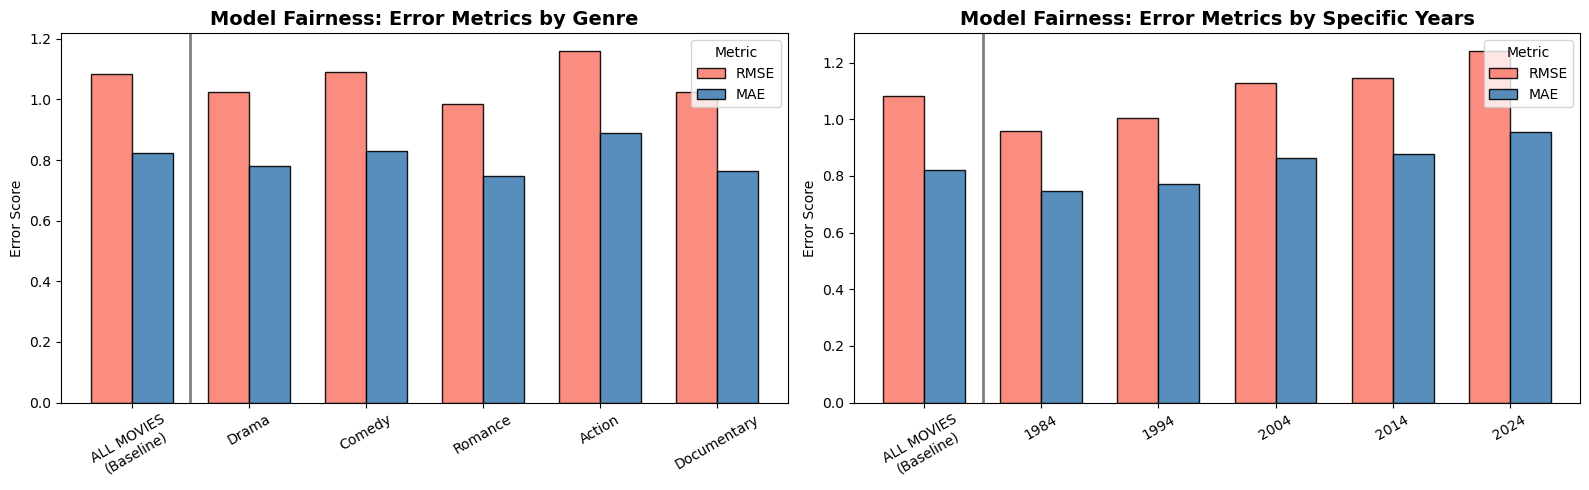

In [48]:

target_years = [1984, 1994, 2004, 2014, 2024]
# בניית הדאטה-פריים של השנים הספציפיות
decade_df = pd.DataFrame([
    slice_metrics(fairness_df[fairness_df['startYear'] == year], f"{year}")
    for year in target_years
    if len(fairness_df[fairness_df['startYear'] == year]) > 0 ])

# ── Tables Side by Side: תצוגת הטבלאות אחת ליד השנייה עם עיצוב נקי ──
style_prefix = "<style>text-align: center; font-family: sans-serif; border-collapse: collapse;</style>"
html_genre = f"<div style='float: left; margin-right: 50px;'><h4>── Error by Genre (Top 5) ──</h4>{genre_df.to_html()}</div>"
html_decade = f"<div style='float: left;'><h4>── Error by Specific Years ──</h4>{decade_df.to_html()}</div>"
# הצגה משולבת שלהן באותה שורה
display_html(style_prefix + html_genre + html_decade, raw=True)

# 1. יצירת שורת "סה"כ כללי" כדי להציג אותה כעמודה פיזית בגרף (ה-Baseline שלנו)
overall_row = pd.DataFrame([{
    'Slice': 'ALL MOVIES\n(Baseline)',
    'RMSE': overall_rmse,
    'MAE': overall_mae}])

# חיבור עמודת הבסיס לראש הטבלאות רק לצורך ציור הגרפים
plot_genre_df  = pd.concat([overall_row, genre_df], ignore_index=True)
plot_decade_df = pd.concat([overall_row, decade_df], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ['salmon', 'steelblue']
# ---------- הגרף השמאלי: ז'אנרים ----------
plot_genre_df.set_index('Slice')[['RMSE', 'MAE']].plot(
    kind='bar', ax=axes[0], color=colors, width=0.7, edgecolor='black', alpha=0.9)
axes[0].set_title('Model Fairness: Error Metrics by Genre', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Error Score')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Metric')
axes[0].axvline(0.5, color='gray', linestyle='-', linewidth=2)

# ---------- הגרף הימני: השנים הנבחרות ----------
plot_decade_df.set_index('Slice')[['RMSE', 'MAE']].plot(
    kind='bar', ax=axes[1], color=colors, width=0.7, edgecolor='black', alpha=0.9)
axes[1].set_title('Model Fairness: Error Metrics by Specific Years', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Error Score')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Metric')
axes[1].axvline(0.5, color='gray', linestyle='-', linewidth=2)

plt.tight_layout()
plt.show()

## 12. שמירת מודל סופי + prepare_data

### prepare_data

מקבלת רק את דאטת התחרות.
ניגשת ל-`df_train_global` שנשמר בזיכרון ה-notebook –
כך הפיצ'רים ההיסטוריים מחושבים על בסיס דאטת האימון.

<div dir="rtl">
כדי שבזמן הגנת הפרויקט הוא יוכל לטעון אותו בשנייה אחת ולבחון אותו על סרטים חדשים, בלי לחכות שהקוד יתאמן מחדש
הקוד הזה ייצור לך קובץ בשם model.pkl בתיקייה, ואותו את מעלה לגיטהאב.
</div>

In [ ]:
#  אימון סופי על כל הדאטה כדי שהמודל יכיל את כל המידע ויגיע למקסימום דיוק
pipeline_rf.fit(X, y)
# 2. שמירת ה-Pipeline המלא (כולל הטרנספורמרים החכמים והמודל הסופי המאומן!)
joblib.dump(pipeline_rf, 'model.pkl')

print(" ה-Pipeline המוביל אומן על כל הנתונים ונשמר בהצלחה כ-model.pkl!")